<a href="https://colab.research.google.com/github/karanmunjal1900/codealpha_task4/blob/main/Disease_Pediction_Model_Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 4 - DISEASE PREDICTION FROM MEDICAL DATA**

Objective:
Predict the possibility of heart disease based on patient medical data.

Approach:
Apply classification techniques using Logistic Regression, SVM, Random Forest, and XGBoost.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving disease.csv to disease.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv("disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Check Missing Values:

In [5]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Check Target Distribution:

In [6]:
print(df['target'].value_counts())

target
1    526
0    499
Name: count, dtype: int64


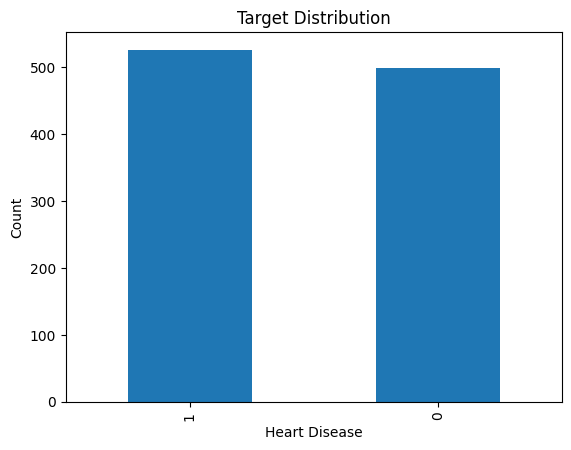

In [7]:
df['target'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

Separate Features and Target:

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

Split Dataset:


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling:

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Logistic Regression:

In [11]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

Train SVM:

In [12]:
svm = SVC(
    probability=True,
    random_state=42
)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_prob = svm.predict_proba(X_test)[:,1]

Train Random Forest:

In [13]:
rf = RandomForestClassifier(
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

Train XGBoost:

In [14]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

Evaluate All Models:

In [15]:
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision :", precision_score(y_test, lr_pred))
print("Recall :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC :", roc_auc_score(y_test, lr_prob))

Logistic Regression
Accuracy : 0.7951219512195122
Precision : 0.7563025210084033
Recall : 0.8737864077669902
F1 Score : 0.8108108108108109
ROC AUC : 0.8787359604035789


In [16]:
print("SVM")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision :", precision_score(y_test, svm_pred))
print("Recall :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))
print("ROC AUC :", roc_auc_score(y_test, svm_prob))

SVM
Accuracy : 0.8878048780487805
Precision : 0.8508771929824561
Recall : 0.941747572815534
F1 Score : 0.8940092165898618
ROC AUC : 0.9631639063392347


In [17]:
print("Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC :", roc_auc_score(y_test, rf_prob))

Random Forest
Accuracy : 0.9853658536585366
Precision : 1.0
Recall : 0.970873786407767
F1 Score : 0.9852216748768473
ROC AUC : 1.0


In [18]:
print("XGBoost")
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision :", precision_score(y_test, xgb_pred))
print("Recall :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC :", roc_auc_score(y_test, xgb_prob))

XGBoost
Accuracy : 0.9853658536585366
Precision : 1.0
Recall : 0.970873786407767
F1 Score : 0.9852216748768473
ROC AUC : 0.9894346087949742


Confusion Matrix:

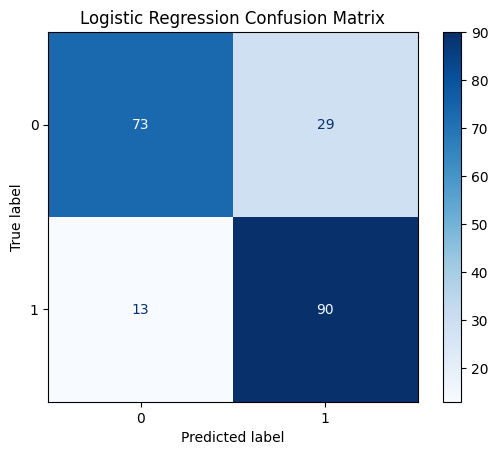

In [19]:
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()




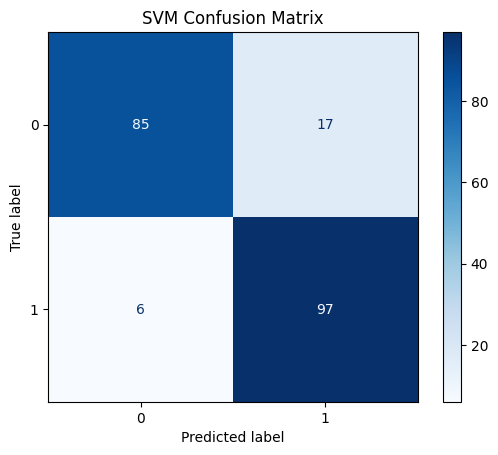

In [20]:
cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.show()


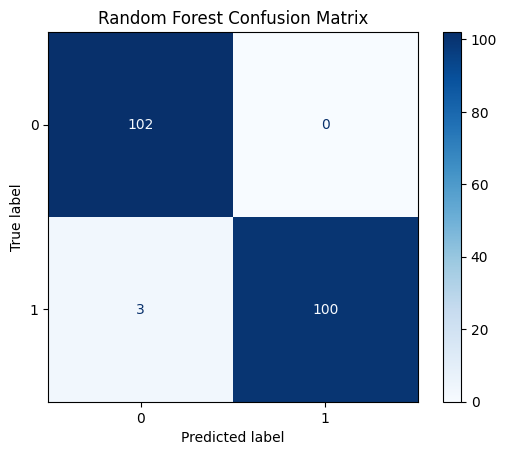

In [21]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

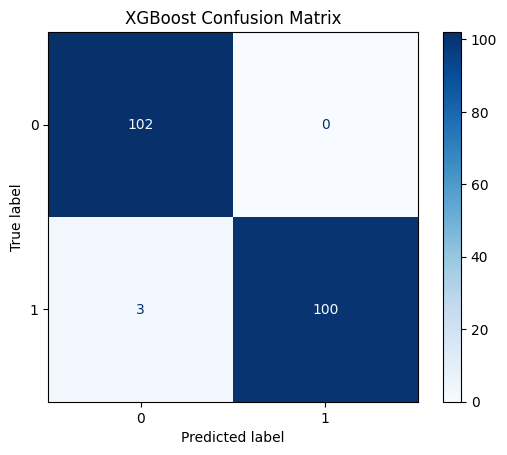

In [22]:
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

Compare All Models:

In [23]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, svm_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.795122   0.756303  0.873786  0.810811  0.878736
1                  SVM  0.887805   0.850877  0.941748  0.894009  0.963164
2        Random Forest  0.985366   1.000000  0.970874  0.985222  1.000000
3              XGBoost  0.985366   1.000000  0.970874  0.985222  0.989435


Plot Model Accuracy:

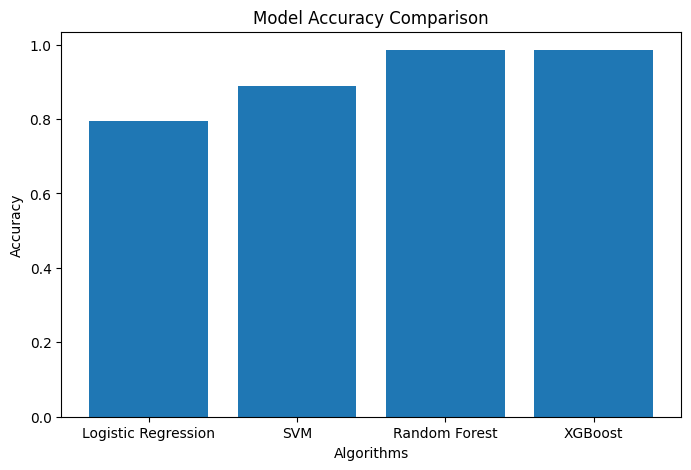

In [24]:
plt.figure(figsize=(8,5))
plt.bar(
    results["Model"],
    results["Accuracy"]
)
plt.title("Model Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

Feature Importance (Random Forest):

In [25]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


PROJECT CONCLUSION:

Heart disease prediction was performed using four machine learning algorithms.
The algorithms used were Logistic Regression, SVM, Random Forest, and XGBoost.

After evaluating all models, the Random Forest algorithm achieved the highest accuracy and is selected as the final prediction model.

In [26]:
import joblib
joblib.dump(
    rf,
    "disease_prediction_model.pkl"
)

['disease_prediction_model.pkl']

In [27]:
from google.colab import files
files.download(
    "disease_prediction_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>